## Lake Zug APhys-AChem Meeting (08.06.2026)

In [267]:
# imports
import ewgreaders as ewg
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

In [3]:
lake = 'Zug'

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

### Thorpe scale

Comapare:
- N basin
- S basin
- Constriction center
- Constriction west
- Constriction east

In [47]:
pl_n = ["P4", "VMPN", "P4'"]
pl_w = ["P6W", "VMPW"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_e = ["P6E"]
pl_s = ["P10", "VMPS", "LZ3", "P10'"]

all_pl = [set(pl_n), set(pl_w), set(pl_c), set(pl_e), set(pl_s)]

#### Days with samples from all locations

In [97]:
data_al = []
for dt, di_ctd_sel in tqdm(di_ctd.groupby('date'), total=di_ctd['date'].nunique()):
    pl = set(di_ctd_sel.profile_loc)
    if all(pl.intersection(basin) for basin in all_pl):
        for _, p in di_ctd_sel.iterrows():
            if p.profile_loc in pl_n + pl_w + pl_c + pl_e + pl_s:
                ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
                ds = ctdreader.load()
                
                if ds['depth'].max() < 110:
                    continue
                
                # select out below 80 meters (hypolimion/deep water)
                ds = ds.sel(depth=slice(80, 110))
                
                # thorpe displacement
                rho = ds['rho']
                depth = ds['depth']
                rho_ra = ewg.signal.rolling_average_z(rho, ra_window=1)
                rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
                thorpe_displacement = depth - rho_ra_sort.depth.values
                thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

                data_al.append({
                    'date': p.date,
                    'profile_loc': p.profile_loc,
                    'basin': 'N' if p.profile_loc in pl_n else 'W' if p.profile_loc in pl_w else 'C' if p.profile_loc in pl_c else 'E' if p.profile_loc in pl_e else 'S',
                    'thorpe_scale': thorpe_scale
                })

data_al = pd.DataFrame(data_al)

  0%|          | 0/39 [00:00<?, ?it/s]

In [98]:
# average within date
data_al_avg = data_al.groupby(['date', 'basin'])['thorpe_scale'].mean().reset_index()

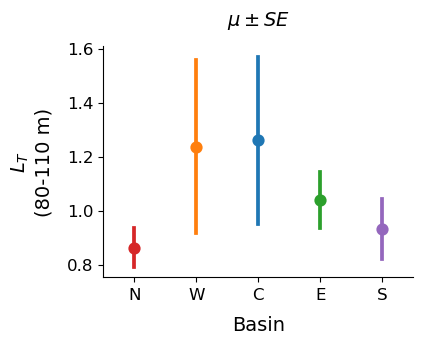

In [379]:
fig, ax = plt.subplots(figsize=(4, 3))
order = ['N', 'W', 'C', 'E', 'S']
palette = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green', 'tab:purple']

#ax.axhline(0, color='black', linestyle='--')
sns.pointplot(data_al_avg, x='basin', y='thorpe_scale', estimator=np.mean, order=order, hue='basin', hue_order=order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax)

ax.set_xlabel('Basin', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax.set_title(r'$\mu \pm SE$', fontsize=14, pad=15)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
#ax.set_ylim(0, None)

plt.savefig('../gallery/zug_aphys_achem/2026_06_08/thorpe_scale_al.svg', bbox_inches='tight')
plt.show()

#### All days

In [84]:
data_ad = []
for _, p in tqdm(di_ctd.iterrows(), total=len(di_ctd)):
    if p.profile_loc in pl_n + pl_w + pl_c + pl_e + pl_s:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        ds = ctdreader.load()

        if ds['depth'].max() < 110:
            continue
        
        # select out below 80 meters (hypolimion/deep water)
        ds = ds.sel(depth=slice(80, 110))
        
        # thorpe displacement
        rho = ds['rho']
        depth = ds['depth']
        rho_ra = ewg.signal.rolling_average_z(rho, ra_window=1)
        rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
        thorpe_displacement = depth - rho_ra_sort.depth.values
        thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

        data_ad.append({
            'date': p.date,
            'profile_loc': p.profile_loc,
            'basin': 'N' if p.profile_loc in pl_n else 'W' if p.profile_loc in pl_w else 'C' if p.profile_loc in pl_c else 'E' if p.profile_loc in pl_e else 'S',
            'thorpe_scale': thorpe_scale
        })

data_ad = pd.DataFrame(data_ad)

  0%|          | 0/288 [00:00<?, ?it/s]

In [85]:
# average within date
data_ad_avg = data_ad.groupby(['date', 'basin'])['thorpe_scale'].mean().reset_index()

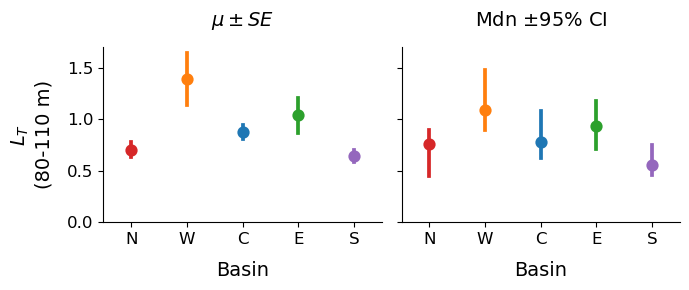

In [380]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), sharey=True)
order = ['N', 'W', 'C', 'E', 'S']
palette = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green', 'tab:purple']

#ax.axhline(0, color='black', linestyle='--')
sns.pointplot(data_ad_avg, x='basin', y='thorpe_scale', estimator=np.mean, order=order, hue='basin', hue_order=order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax[0])
sns.pointplot(data_ad_avg, x='basin', y='thorpe_scale', estimator=np.median, order=order, hue='basin', hue_order=order, palette=palette, errorbar=('ci', 95), linestyle='none', ax=ax[1])

ax[0].set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax[0].set_title(r'$\mu \pm SE$', fontsize=14, pad=15)
ax[1].set_title(r'Mdn $\pm$' + '95% CI', fontsize=14, pad=15)

for i in range(len(ax)):
    ax[i].set_xlabel('Basin', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
   
ax[0].set_ylim(0, None)

plt.tight_layout()
plt.savefig('../gallery/zug_aphys_achem/2026_06_08/thorpe_scale_ad.svg', bbox_inches='tight')
plt.show()

### Temperature Overturns

Compare:
- Constriction center
- Constriction west
- Constriction east

In [118]:
def load_thermistor_chain(di, t_start='2026-02-06', t_end='2026-04-08'):
    all_temp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        treader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
        ds = treader.load().sel(time=slice(t_start, t_end))
        all_temp.append(ds)

    ds_temp = mreader.create_instrument_chain(all_temp)

    return ds_temp

In [120]:
date = '2026-04-09'
thermistors = ['rbr_temp', 'rbr_duet']
di_m_sel = di_m.query("date == @date and sensor in @thermistors")

# LZW
di_w = di_m_sel.query("location == 'LZW'")
ds_temp_w = load_thermistor_chain(di_w).temp

# LZC
di_c = di_m_sel.query("location == 'LZC'")
ds_temp_c = load_thermistor_chain(di_c).temp

# LZE
di_e = di_m_sel.query("location == 'LZE'")
ds_temp_e = load_thermistor_chain(di_e).temp

C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\2649458886.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and sensor in @thermistors")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a fut

In [121]:
z_min = 100
z_max = 105

tw_top = ds_temp_w.sel(depth=z_min, method='nearest')
tw_bot = ds_temp_w.sel(depth=z_max, method='nearest')

tc_top = ds_temp_c.sel(depth=z_min, method='nearest')
tc_bot = ds_temp_c.sel(depth=z_max, method='nearest')

te_top = ds_temp_e.sel(depth=z_min, method='nearest')
te_bot = ds_temp_e.sel(depth=z_max, method='nearest')

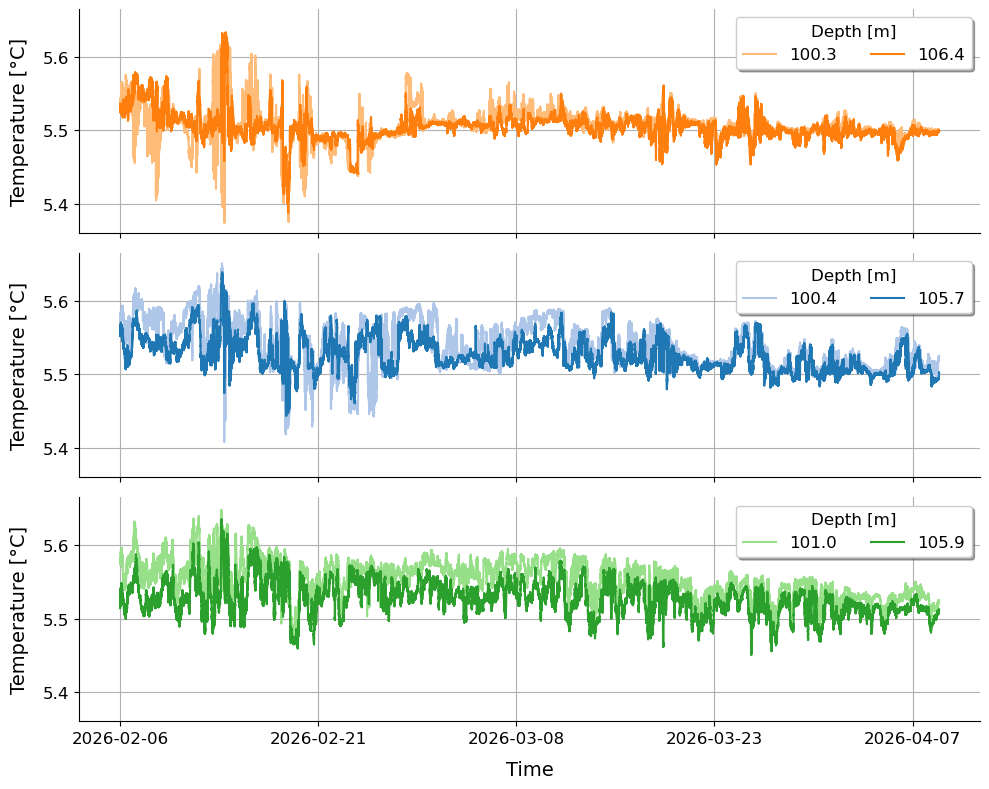

In [381]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
palette = sns.color_palette('tab20', n_colors=6)

# LZW
sns.lineplot(x=tw_top.time, y=tw_top, color=palette[3], ax=ax[0], label=tw_top.depth.item())
sns.lineplot(x=tw_bot.time, y=tw_bot, color=palette[2], ax=ax[0], label=tw_bot.depth.item())

# LZC
sns.lineplot(x=tc_top.time, y=tc_top, color=palette[1], ax=ax[1], label=tc_top.depth.item())
sns.lineplot(x=tc_bot.time, y=tc_bot, color=palette[0], ax=ax[1], label=tc_bot.depth.item())

# LZE
sns.lineplot(x=te_top.time, y=te_top, color=palette[5], ax=ax[2], label=te_top.depth.item())
sns.lineplot(x=te_bot.time, y=te_bot, color=palette[4], ax=ax[2], label=te_bot.depth.item())

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[2].xaxis.set_major_locator(mdates.DayLocator(interval=15))

for i in range(len(ax)):
    ax[i].set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    ax[i].legend(ncols=2, title='Depth [m]', fontsize=12, title_fontsize=12, shadow=True, loc='upper right')

plt.tight_layout()
plt.savefig('../gallery/zug_aphys_achem/2026_06_08/temp_overturn_ts.svg', bbox_inches='tight')
plt.show()

In [130]:
overturn_tw = tw_top < tw_bot
overturn_tc = tc_top < tc_bot
overturn_te = te_top < te_bot

df_tow = overturn_tw.groupby('time.date').mean().to_dataframe().reset_index()
df_tow['location'] = 'W'

df_toc = overturn_tc.groupby('time.date').mean().to_dataframe().reset_index()
df_toc['location'] = 'C'

df_toe = overturn_te.groupby('time.date').mean().to_dataframe().reset_index()
df_toe['location'] = 'E'

df_to = pd.concat([df_tow, df_toc, df_toe], ignore_index=True)

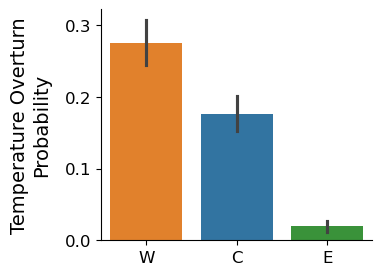

In [382]:
fig, ax = plt.subplots(figsize=(3.5, 3))
order = ['W', 'C', 'E']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.barplot(df_to, x='location', y='temp', order=order, hue='location', hue_order=order, palette=palette, errorbar=('se', 1), ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Temperature Overturn\nProbability', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_aphys_achem/2026_06_08/temp_overturn_prop.svg', bbox_inches='tight')
plt.show()

### Oxygen overturns

In [137]:
def load_oxygen_logger_chain(di, t_start='2026-02-06', t_end='2026-04-08'):
    all_do = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        oreader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
        ds = oreader.load().sel(time=slice(t_start, t_end))
        ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()    # anoxic?
        all_do.append(ds)

    ds_do = mreader.create_instrument_chain(all_do)

    return ds_do

In [138]:
date = '2026-04-09'
oxygen_loggers = ['minidot']
di_m_sel = di_m.query("date == @date and sensor in @oxygen_loggers")

# LZW
di_w = di_m_sel.query("location == 'LZW'")
ds_do_w = load_oxygen_logger_chain(di_w).do2_conc

# LZC
di_c = di_m_sel.query("location == 'LZC'")
ds_do_c = load_oxygen_logger_chain(di_c).do2_conc

# LZE
di_e = di_m_sel.query("location == 'LZE'")
ds_do_e = load_oxygen_logger_chain(di_e).do2_conc

C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\2028166213.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and sensor in @oxygen_loggers")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a 

In [139]:
z_min = 100
z_max = 105

ow_top = ds_do_w.sel(depth=z_min, method='nearest')
ow_bot = ds_do_w.sel(depth=z_max, method='nearest')

oc_top = ds_do_c.sel(depth=z_min, method='nearest')
oc_bot = ds_do_c.sel(depth=z_max, method='nearest')

oe_top = ds_do_e.sel(depth=z_min, method='nearest')
oe_bot = ds_do_e.sel(depth=z_max, method='nearest')

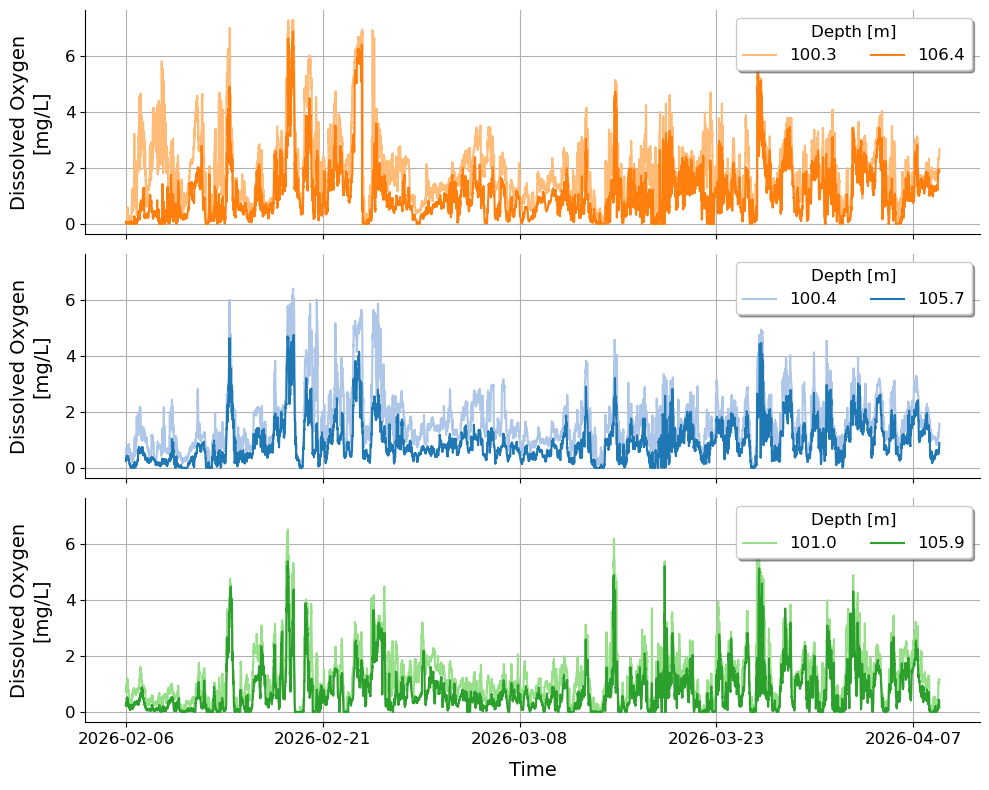

In [383]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
palette = sns.color_palette('tab20', n_colors=6)

# LZW
sns.lineplot(x=ow_top.time, y=ow_top, color=palette[3], ax=ax[0], label=ow_top.depth.item())
sns.lineplot(x=ow_bot.time, y=ow_bot, color=palette[2], ax=ax[0], label=ow_bot.depth.item())

# LZC
sns.lineplot(x=oc_top.time, y=oc_top, color=palette[1], ax=ax[1], label=oc_top.depth.item())
sns.lineplot(x=oc_bot.time, y=oc_bot, color=palette[0], ax=ax[1], label=oc_bot.depth.item())

# LZE
sns.lineplot(x=oe_top.time, y=oe_top, color=palette[5], ax=ax[2], label=oe_top.depth.item())
sns.lineplot(x=oe_bot.time, y=oe_bot, color=palette[4], ax=ax[2], label=oe_bot.depth.item())

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[2].xaxis.set_major_locator(mdates.DayLocator(interval=15))

for i in range(len(ax)):
    ax[i].set_ylabel('Dissolved Oxygen\n[mg/L]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    ax[i].legend(ncols=2, title='Depth [m]', fontsize=12, title_fontsize=12, shadow=True, loc='upper right')

plt.tight_layout()
plt.savefig('../gallery/zug_aphys_achem/2026_06_08/o2_overturn_ts.svg', bbox_inches='tight')
plt.show()

In [141]:
overturn_ow = ow_top < ow_bot
overturn_oc = oc_top < oc_bot
overturn_oe = oe_top < oe_bot

df_oow = overturn_ow.groupby('time.date').mean().to_dataframe().reset_index()
df_oow['location'] = 'W'

df_ooc = overturn_oc.groupby('time.date').mean().to_dataframe().reset_index()
df_ooc['location'] = 'C'

df_ooe = overturn_oe.groupby('time.date').mean().to_dataframe().reset_index()
df_ooe['location'] = 'E'

df_oo = pd.concat([df_oow, df_ooc, df_ooe], ignore_index=True)

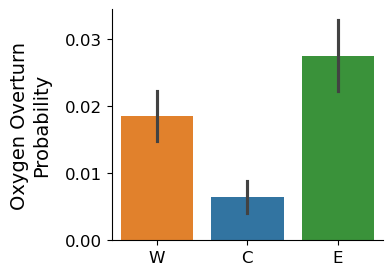

In [384]:
fig, ax = plt.subplots(figsize=(3.5, 3))
order = ['W', 'C', 'E']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.barplot(df_oo, x='location', y='do2_conc', order=order, hue='location', hue_order=order, palette=palette, errorbar=('se', 1), ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Oxygen Overturn\nProbability', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_aphys_achem/2026_06_08/o2_overturn_prop.svg', bbox_inches='tight')
plt.show()

### Horizontal flow speed and overturning

In [402]:
def load_adcp_chain(di, gap):
    # ADCP
    all_adcp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
        ds = areader.load().sel(time=slice(t_start, t_end))
        ds['depth'] = ds['depth'].round(0)
        ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data
        all_adcp.append(ds)

    # shared time axis as mean of each instruments times
    time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
    all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

    # concatenate datasets and average common range bins
    ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
    ds_adcp = ds_adcp.sortby('depth')
    ds_adcp = ds_adcp.groupby('depth').mean()

    # don't interplate over gap from opposite looking ADCPs in double frame
    full_depth = np.sort(np.concatenate([ds_adcp.depth.values, gap]))
    ds_adcp = ds_adcp.reindex(depth=full_depth)

    return ds_adcp

In [403]:
date = '2026-01-14'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(67, 77)
ds_adcp = load_adcp_chain(di_m_sel, gap).sel(depth=slice(80, 110))

# horizontal flow speed
u1 = ds_adcp.vel.sel(dir='E')
v1 = ds_adcp.vel.sel(dir='N')
speed1 = np.sqrt(u1**2 + v1**2).mean(dim='depth')

# z-score
s1_z = (speed1 - speed1.mean()) / speed1.std(ddof=1)

# 1-hour rolling average
s1_ra = speed1.rolling(time=6, center=True).mean()

# vertical shear
S21 = ewg.datsci.efd.vertical_shear(ds_adcp.vel).mean(dim='depth')

C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\309385806.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [404]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(77, 87)
ds_adcp = load_adcp_chain(di_m_sel, gap).sel(depth=slice(80, 110))

# horizontal flow speed
u2 = ds_adcp.vel.sel(dir='E')
v2 = ds_adcp.vel.sel(dir='N')
speed2 = np.sqrt(u2**2 + v2**2).mean(dim='depth')

# z-score
s2_z = (speed2 - speed2.mean()) / speed2.std(ddof=1)

# 1-hour rolling average
s2_ra = speed2.rolling(time=6, center=True).mean()

# vertical shear
S22 = ewg.datsci.efd.vertical_shear(ds_adcp.vel).mean(dim='depth')

C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\1157616528.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [405]:
u = xr.concat([abs(u1).mean(dim='depth'), abs(u2).mean(dim='depth')], dim='time')
v = xr.concat([abs(v1).mean(dim='depth'), abs(v2).mean(dim='depth')], dim='time')
speed = xr.concat([speed1, speed2], dim='time')
s_z = xr.concat([s1_z, s2_z], dim='time')
s_ra = xr.concat([s1_ra, s2_ra], dim='time')
S2 = xr.concat([S21, S22], dim='time')

In [406]:
di_ctd_sel = di_ctd[(di_ctd['date'].between(s_ra.time.values[0], s_ra.time.values[-1])) & (di_ctd['profile_loc'].isin(pl_c))]

data_c = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    if ds['depth'].max() < 110:
            continue
        
    # select out below 80 meters (hypolimion/deep water)
    ds = ds.sel(depth=slice(80, 110))

    # flow speed, vertical shear 30 minutes prior to profile
    tf = ds['time'].values[0]
    t0 = tf - pd.Timedelta(minutes=30)
    u_vel = u.sel(time=slice(t0, tf)).mean().item()
    v_vel = v.sel(time=slice(t0, tf)).mean().item()
    s = speed.sel(time=slice(t0, tf)).mean().item()
    sz = s_z.sel(time=slice(t0, tf)).mean().item()
    shear = S2.sel(time=slice(t0, tf)).mean().item()
    
    # thorpe displacement
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = ewg.signal.rolling_average_z(rho, ra_window=1)
    rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    data_c.append({
        'date': p.date,
        'time': tf,
        'profile_loc': p.profile_loc,
        'thorpe_scale': thorpe_scale,
        'u': u_vel,
        'v': v_vel,
        'speed': s,
        'speed_z': sz,
        'S2': shear
    })

data_c = pd.DataFrame(data_c).dropna()

  0%|          | 0/51 [00:00<?, ?it/s]

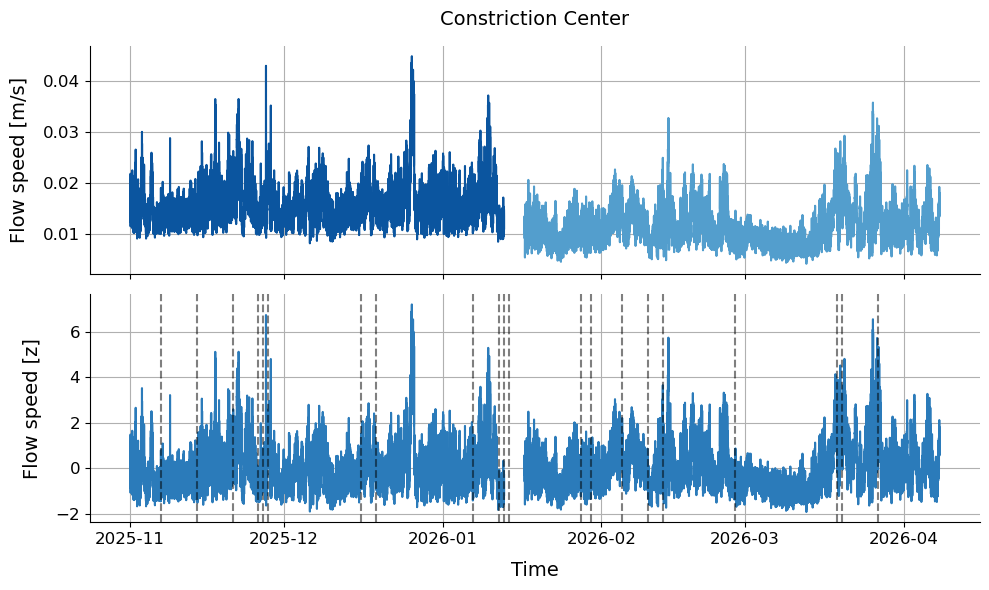

In [407]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
palette = sns.color_palette('Blues')

sns.lineplot(x=speed1.time, y=speed1, color=palette[-1], ax=ax[0])
sns.lineplot(x=speed2.time, y=speed2, color=palette[-3], ax=ax[0])

sns.lineplot(x=s1_z.time, y=s1_z, color=palette[-2], ax=ax[1])
sns.lineplot(x=s2_z.time, y=s2_z, color=palette[-2], ax=ax[1])

for dt in di_ctd_sel.date.unique():
    ax[1].axvline(dt, color='black', linestyle='--', alpha=0.5)

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Flow speed [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Flow speed [z]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction Center', fontsize=14, pad=15)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
plt.savefig('../gallery/zug_aphys_achem/2026_06_08/flow_speed.svg', bbox_inches='tight')
plt.show()

In [408]:
r, p = scipy.stats.pearsonr(data_c.speed_z, data_c.thorpe_scale, alternative='two-sided')

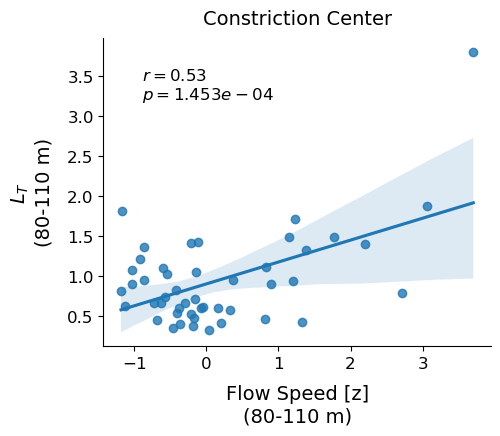

In [409]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.regplot(data_c, x='speed_z', y='thorpe_scale', color='tab:blue', ax=ax)

txtstr = f'$r = {r:.2f}$\n$p = {p:.3e}$' if p < 0.001 else f'$r = {r:.2f}$\n$p = {p:.3f}$'
ax.annotate(txtstr, xy=(0.1, 0.8), xycoords='axes fraction', fontsize=12)

ax.set_xlabel('Flow Speed [z]\n(80-110 m)', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax.set_title('Constriction Center', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_aphys_achem/2026_06_08/speed_z_thorpe.svg', bbox_inches='tight')
plt.show()

### Oxygen overturn within anoxic zone

In [410]:
date = '2026-03-20'
di_sel = di_ctd.query("date == @date")

p = di_sel.iloc[4]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds = ctdreader.load()
ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()    # anoxic
ds['do2_conc'] = ds['do2_conc'] * (1000/32)               # convert to umol/L

C:\Users\herremha\AppData\Local\Temp\ipykernel_27976\3476739476.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_sel = di_ctd.query("date == @date")


In [411]:
do_ra = ewg.datsci.signal.rolling_average_z(ds['do2_conc'], ra_window=1)

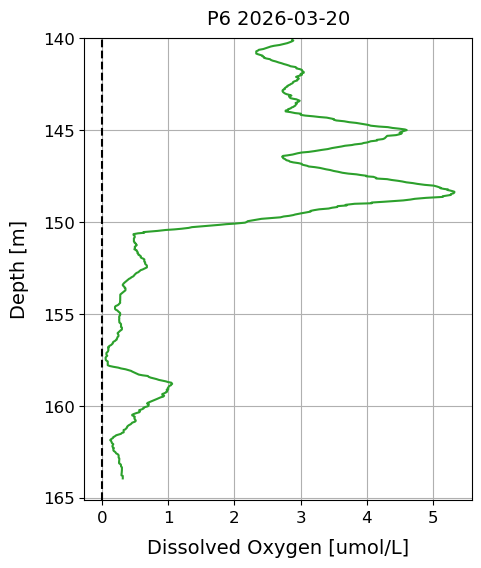

In [412]:
z_min = 140
do_ra_sel = do_ra.sel(depth=slice(z_min, None))

fig, ax = plt.subplots(figsize=(5, 6))

ax.axvline(0, color='black', linestyle='--')
sns.lineplot(x=do_ra_sel, y=do_ra_sel.depth, orient='y', color='tab:green', ax=ax)

ax.set_xlabel('Dissolved Oxygen [umol/L]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title(p.profile_loc + ' ' + date, fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(z_min, None)
ax.invert_yaxis()
ax.grid(True)

plt.savefig('../gallery/zug_aphys_achem/2026_06_08/o2_overturn_anoxic.svg', bbox_inches='tight')
plt.show()

### Thorpe scale

Compare:
- Constriction center
- Constriction north
- Constriction south

In [54]:
pl_nc = ["P5", "P5'", "P5''"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_sc = ["P8", "P9", "P9'"]

all_plc = [set(pl_nc), set(pl_c), set(pl_sc)]

In [58]:
data = []
for dt, di_ctd_sel in tqdm(di_ctd.groupby('date'), total=di_ctd['date'].nunique()):
    pl = set(di_ctd_sel.profile_loc)
    if all(pl.intersection(basin) for basin in all_plc):
        for _, p in di_ctd_sel.iterrows():
            if p.profile_loc in pl_nc + pl_c + pl_sc:
                ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
                ds = ctdreader.load()
                
                if ds['depth'].max() < 110:
                    continue
                
                # select out below 80 meters (hypolimion/deep water)
                ds = ds.sel(depth=slice(80, 110))
                
                # thorpe displacement
                rho = ds['rho']
                depth = ds['depth']
                rho_ra = ewg.signal.rolling_average_z(rho, ra_window=1)
                rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
                thorpe_displacement = depth - rho_ra_sort.depth.values
                thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

                data.append({
                    'date': p.date,
                    'profile_loc': p.profile_loc,
                    'basin': 'NC' if p.profile_loc in pl_nc else 'C' if p.profile_loc in pl_c else 'SC',
                    'thorpe_scale': thorpe_scale
                })

data = pd.DataFrame(data)

  0%|          | 0/39 [00:00<?, ?it/s]

In [59]:
# average within date
data_avg = data.groupby(['date', 'basin'])['thorpe_scale'].mean().reset_index()

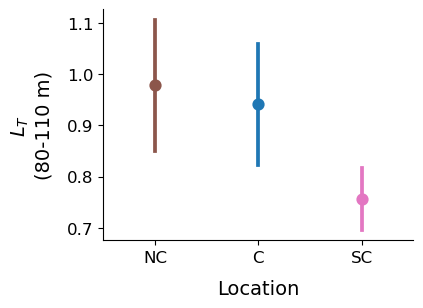

In [61]:
fig, ax = plt.subplots(figsize=(4, 3))
order = ['NC', 'C', 'SC']
palette = ['tab:brown', 'tab:blue', 'tab:pink']

#ax.axhline(0, color='black', linestyle='--')
sns.pointplot(data_avg, x='basin', y='thorpe_scale', estimator=np.mean, order=order, hue='basin', hue_order=order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax)

ax.set_xlabel('Location', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
#ax.set_ylim(0, None)

#plt.savefig('../../gallery/unil_field_camp/2026/thorpe_scale_basin.svg', bbox_inches='tight')
plt.show()